# Thermal Data Collection

THEMIS brightness-temperature windows for every landform in the optical data set.

Run `../../data_overview.ipynb` first: it builds
`data/optical/final_data/annotations.json`, which this notebook keys off.

## Why thermal at all

Cushing et al. (2007) identify a cave skylight not by how warm it is but by how
*little* its temperature swings: a cave-connected pit shows a **smaller diurnal
amplitude than the collapse pits beside it** -- warmer than its surroundings at
night, cooler than sunlit ground in the afternoon. That is exactly the
Type-1-versus-rest discrimination the optical model is being asked to make, so
the thermal channel is not decoration here; it is the physically motivated
second opinion on the same boundary.

| stage | code |
|---|---|
| 1. one query site per landform | `data/thermal/thermal_sites.py` |
| 2. which observations cover each site | `collect.find_observations` |
| 3. fetch the pixels | `collect.extract_windows` |
| 4. what the model receives | `model/landform_dataset.py` |

Both retrieval stages hit remote archives. They are guarded by flags and cache
to disk, so re-running this notebook does not re-download anything.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import os
import sys

# This notebook lives two levels down; anchor everything to the repository root
# so the paths hold whatever directory Jupyter was started from.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data.thermal.collect import WINDOW_PX, extract_windows, find_observations
from data.thermal.thermal_sites import landform_sites
from model.landform_dataset import LandformDataset

ANNOTATIONS = "data/optical/final_data/annotations.json"
THERMAL_DIR = "data/thermal"
THEMIS_DIR = os.path.join(THERMAL_DIR, "themis_data")
WINDOWS_DIR = os.path.join(THEMIS_DIR, "windows")
OBSERVATIONS = os.path.join(THEMIS_DIR, "observations.csv")
MANIFEST = os.path.join(THEMIS_DIR, "window_manifest.json")

print("repo root:", REPO_ROOT)
print("windows  :", WINDOWS_DIR)

repo root: C:\Users\Utente\Desktop\lavatube_paper
windows  : data/thermal\themis_data\windows


## 1. One query site per landform

A site is a **landform** -- the same feature across its resolution replicas and
across repeat observations -- identified with the *same* grouping the training
split uses, so a thermal site and a cross-validation group are the same object
by construction.

This replaced a 0.05 degree grid. The grid was wrong in a way that mattered:
0.05 degrees is ~2.96 km at the equator against a 3.2 km window, so the step was
nearly the whole window rather than half of it. The true landform centre sat a
median of **1138 m** -- 11.4 THEMIS pixels -- from the window centre, and 10.7%
of landforms fell outside their own window entirely. Keyed to landforms the
median offset is **1 m**.

In [2]:
annotations = pd.read_json(ANNOTATIONS)
dataset = LandformDataset(annotations, root_dir=".")

sites, annotation_sites = landform_sites(
    annotations, dataset.group_keys(level="landform")
)
sites.head()

1846 annotations -> 318 landform sites
  annotations per site : median 5, max 20
  member span (m)      : median 2, 90th 76, max 5951
  sites spanning >300 m (3 THEMIS px): 2
  written to data/thermal/landform_sites.csv and data/thermal/annotation_sites.csv


,lat,lon_east,n_annotations,span_m,category_ids,site_id
0,-21.302329,239.360773,5,4.030960,[2],lf_0000
1,-21.293455,239.362804,5,2.266500,[2],lf_0001
2,-21.284510,239.364826,5,2.830421,[2],lf_0002
3,-21.273549,239.369106,5,2.790829,[2],lf_0003
4,-21.263379,239.373088,5,3.525622,[2],lf_0004


## 2. Which observations cover each site

`find_observations` queries the ODE ArcGIS footprint layer for THEMIS IRPBT4,
once per site, and returns observation ids with acquisition time, Mars local
solar time and viewing geometry.

**Live network calls.** Cached to `observations.csv`; set `REFETCH = True` to
query again.

In [3]:
REFETCH = False

if REFETCH or not os.path.exists(OBSERVATIONS):
    observations = find_observations(sites, out_path=OBSERVATIONS)
else:
    observations = pd.read_csv(OBSERVATIONS)
    print(f"loaded {len(observations)} cached observations")

covered = observations["site_id"].nunique()
per_site = observations.groupby("site_id").size()

print(f"{len(observations)} observations, {covered}/{len(sites)} sites covered")
print(f"  {observations['observation_id'].nunique()} distinct products")
print(f"  observations per site: median {per_site.median():.0f}, "
      f"min {per_site.min()}, max {per_site.max()}")
print(f"  sites with at least 3: {(per_site >= 3).sum()}/{len(per_site)}")

loaded 2588 cached observations
2588 observations, 314/318 sites covered
  579 distinct products
  observations per site: median 7, min 1, max 20
  sites with at least 3: 302/314


## 3. What local solar times actually exist

This is the constraint the whole thermal argument runs into, so it is worth
looking at before extracting anything.

Cushing's test needs an afternoon pass (\~15-17 h) *and* a predawn pass
(\~03-05 h) to measure a diurnal amplitude. Mars Odyssey flies a near
sun-synchronous orbit whose local time has drifted over the mission, so what a
site actually gets is whatever the orbit happened to offer.

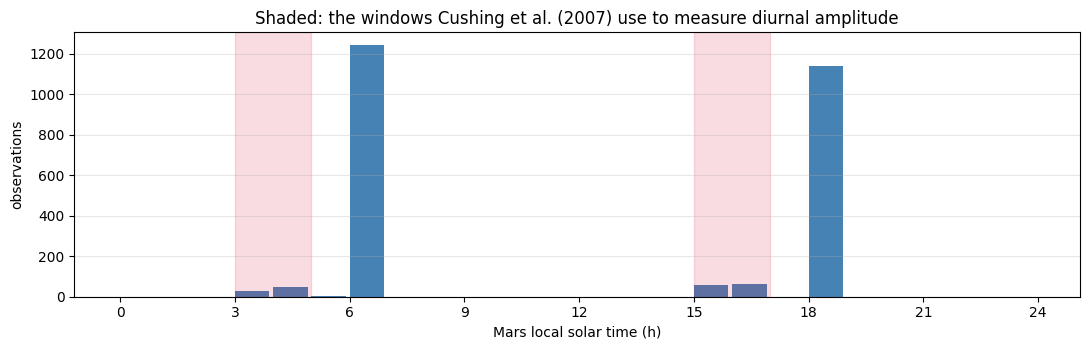

199 of 2588 observations (8%) fall in a diagnostic window.
The rest sit near the terminator, where the surface is close to its
thermal minimum at both ends of the day. A sequence can therefore span
12 hours of local time and still sample two thermally similar states.


In [4]:
hours = observations["mars_lmst_decimal_hours"].dropna()
counts, edges = np.histogram(hours, bins=24, range=(0, 24))

diagnostic = ((hours.between(15, 17)) | (hours.between(3, 5))).sum()

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(edges[:-1], counts, width=0.9, align="edge", color="steelblue")
ax.axvspan(3, 5, color="crimson", alpha=0.15)
ax.axvspan(15, 17, color="crimson", alpha=0.15)
ax.set_xlabel("Mars local solar time (h)")
ax.set_ylabel("observations")
ax.set_title("Shaded: the windows Cushing et al. (2007) use to measure "
             "diurnal amplitude")
ax.set_xticks(range(0, 25, 3))
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"{diagnostic} of {len(hours)} observations "
      f"({100 * diagnostic / len(hours):.0f}%) fall in a diagnostic window.")
print("The rest sit near the terminator, where the surface is close to its")
print("thermal minimum at both ends of the day. A sequence can therefore span")
print("12 hours of local time and still sample two thermally similar states.")

## 4. Fetch the pixels

`extract_windows` opens each product through GDAL's `/vsicurl/` and reads only
the bytes covering the window, so a 32x32 patch costs a few kilobytes rather
than the 0.4-126 MB the whole product would. Downloading products outright would
have been roughly 14 GB; this is a few megabytes.

Frames per site are chosen by greedy farthest-point selection on the 24 h
circle, which takes whatever diurnal spread genuinely exists instead of
targeting clock hours that may not be there.

Windows are extracted at `WINDOW_PX = 32`. Any smaller window is a *centred
slice* of that, taken at training time, so narrowing later costs nothing and
needs no refetch.

**Live network calls**, about 20 minutes for the full set.

In [5]:
REEXTRACT = False

if REEXTRACT or not os.path.exists(MANIFEST):
    manifest = extract_windows(observations, sequence_length=3,
                               window_px=WINDOW_PX)
else:
    with open(MANIFEST) as handle:
        manifest = json.load(handle)
    print(f"loaded manifest for {len(manifest)} sites")

frames = pd.DataFrame([
    {"site_id": entry["site_id"], **frame}
    for entry in manifest for frame in entry["frames"]
])
per_site_frames = pd.Series([e["n_frames"] for e in manifest])

print(f"{len(manifest)} sites, {len(frames)} frames")
print(f"  frames per site: {per_site_frames.value_counts().sort_index().to_dict()}")
print(f"  frames with no valid pixel: {int(frames.kelvin_median.isna().sum())}")
print(f"  frames under 50% valid    : {int((frames.valid_fraction < 0.5).sum())}")

loaded manifest for 314 sites
314 sites, 928 frames
  frames per site: {1: 2, 2: 10, 3: 302}
  frames with no valid pixel: 81
  frames under 50% valid    : 124


## 5. What was retrieved

The two numbers that decide whether any of this is usable: how far apart in
local time a site's frames are, and how much its temperature actually moves
between them.

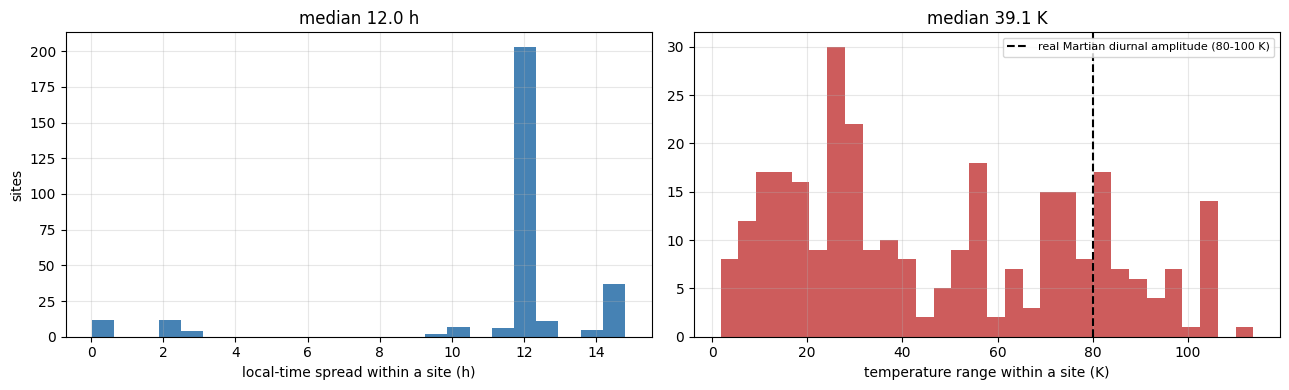

sites with at least 2 usable frames: 299/314
  local-time spread : median 12.0 h
  temperature range : median 39.1 K, 10th 11.9, 90th 90.0
  sites under 10 K  : 23

A ~12 hour spread yielding ~39 K, against a real diurnal amplitude of
80-100 K, is the terminator sampling showing up in the measurement.


In [6]:
usable = frames.dropna(subset=["kelvin_median"])
multi = usable.groupby("site_id").filter(lambda g: len(g) >= 2).groupby("site_id")

delta_k = multi["kelvin_median"].agg(lambda s: s.max() - s.min())
delta_t = multi["mars_lmst_decimal_hours"].agg(lambda s: s.max() - s.min())

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].hist(delta_t, bins=24, color="steelblue")
axs[0].set_xlabel("local-time spread within a site (h)")
axs[0].set_ylabel("sites")
axs[0].set_title(f"median {delta_t.median():.1f} h")

axs[1].hist(delta_k, bins=30, color="indianred")
axs[1].axvline(80, ls="--", c="black", lw=1.5,
               label="real Martian diurnal amplitude (80-100 K)")
axs[1].set_xlabel("temperature range within a site (K)")
axs[1].set_title(f"median {delta_k.median():.1f} K")
axs[1].legend(fontsize=8)
for ax in axs:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"sites with at least 2 usable frames: {len(delta_k)}/{len(manifest)}")
print(f"  local-time spread : median {delta_t.median():.1f} h")
print(f"  temperature range : median {delta_k.median():.1f} K, "
      f"10th {delta_k.quantile(0.1):.1f}, 90th {delta_k.quantile(0.9):.1f}")
print(f"  sites under 10 K  : {int((delta_k < 10).sum())}")
print()
print("A ~12 hour spread yielding ~39 K, against a real diurnal amplitude of")
print("80-100 K, is the terminator sampling showing up in the measurement.")

## 6. What the model receives

`LandformDataset.thermal_for` returns `(T, 2, k, k)`, and `thermal_time_for` the matching `(T, 5)` of local solar time and season:

* **channel 0** -- brightness temperature, standardised using the mean and
  standard deviation of the **valid pixels only**;
* **channel 1** -- a validity mask, 1 where a real measurement exists.

Missing values in channel 0 are filled with the dataset mean, which standardises
to exactly 0.

Why a mask channel rather than a sentinel such as -1 in a single channel:

* **A sentinel corrupts the statistics.** 13.8% of pixels are missing. Any
  out-of-range fill drags the mean by tens of Kelvin and inflates the standard
  deviation, and `ThermalEncoder` runs `BatchNorm2d`, so two sites with identical
  physics but different coverage would normalise differently.
* **Missingness is spatial.** Frames are not simply present or absent -- many are
  partially valid, with holes inside the window. A 3x3 convolution over a
  sentinel hole beside real terrain emits a blend the network then has to learn
  to undo. The mask rides through the same convolutions and hands every layer a
  spatially aligned "how much of this was real".

The mask does **not** remove the availability leak -- coverage still correlates
with class and the model can read the mask. It makes the leak a named input that
can be ablated and measured; `data_overview.ipynb` section 7 quantifies it.

thermal tensor (3, 2, 32, 32)  (T, channels, k, k)
  normalisation from valid pixels: 187.7 K, 28.6 K
  channel 1 values: [0.0, 1.0]


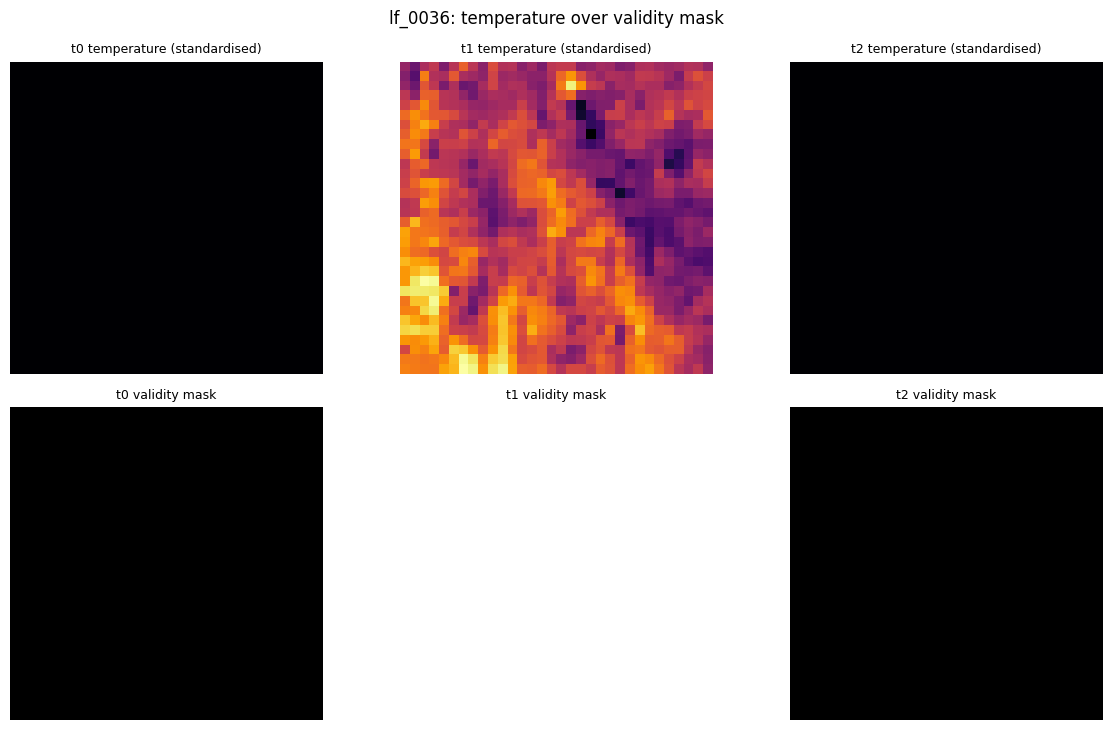

In [7]:
thermal_dataset = LandformDataset(
    annotations, root_dir=".", out_px=128,
    thermal_sites=annotation_sites["site_id"].tolist(),
    thermal_dir=WINDOWS_DIR,
)

_, thermal, thermal_time, _ = thermal_dataset[0]
print(f"thermal tensor {tuple(thermal.shape)}  (T, channels, k, k)")
print(f"  normalisation from valid pixels: "
      f"{thermal_dataset.thermal_mean:.1f} K, {thermal_dataset.thermal_std:.1f} K")
print(f"  channel 1 values: {sorted(set(thermal[:, 1].flatten().tolist()))}")

# A site with partial coverage, to show the mask doing its job.
coverage = np.array([float(e["n_frames"]) for e in manifest])
example_site = manifest[int(np.argmin(np.abs(coverage - 2)))]["site_id"]
row = annotation_sites.index[annotation_sites.site_id == example_site][0]
_, example, example_time, _ = thermal_dataset[row]

fig, axs = plt.subplots(2, example.shape[0], figsize=(4 * example.shape[0], 7.4))
for t in range(example.shape[0]):
    axs[0, t].imshow(example[t, 0], cmap="inferno")
    axs[0, t].set_title(f"t{t} temperature (standardised)", fontsize=9)
    axs[1, t].imshow(example[t, 1], cmap="gray", vmin=0, vmax=1)
    axs[1, t].set_title(f"t{t} validity mask", fontsize=9)
for ax in axs.ravel():
    ax.axis("off")
fig.suptitle(f"{example_site}: temperature over validity mask")
plt.tight_layout()
plt.show()

## 7. Where this leaves the thermal argument

**What works.** Retrieval is complete and correctly targeted: 302 of 314 sites
carry a full three-frame sequence, the window is centred on the landform to
within a metre, and the whole set costs a few megabytes of range reads.

**What does not.** The archive available here is overwhelmingly near-terminator.
Sequences span ~12 hours of local time and still yield a median range of ~39 K
against a real diurnal amplitude of 80-100 K, because both ends of the day sit
close to the thermal minimum. Cushing's amplitude test cannot be reproduced at
the scale the catalogue needs.

**Resolution, by contrast, is not the binding constraint -- which is worth
stating because it is easy to assume otherwise.** A THEMIS pixel is ~100 m and
the median Type-1 skylight is 155 m across, so the naive reading is that the
targets are sub-pixel. They are not. Under random sub-pixel alignment the median
skylight fills 84% of its best-covered pixel, and even a 54 m skylight -- the
10th percentile -- fills 18%. A cave signature of 40 K would therefore arrive as
34 K and 7 K respectively, both far above a ~3 K floor at THEMIS NEdT of ~1 K.

Cushing's ~100 m guidance is about *confidently identifying* a candidate, not
about whether a thermal anomaly clears the noise, and the two thresholds are not
the same. What actually blocks the measurement here is **when** the observations
were taken, not how big the pixels are.

Next:

1. **Route (b): THEMIS global day/night IR mosaics and thermal inertia.** Uniform
   coverage at known local times, no per-site revisit lottery. Costs the
   time-series framing -- the temporal branch becomes a two-channel input -- but
   the data here is not a time series in any useful sense anyway.
2. **The synthetic arm, as a resolution sweep.** Generate thermal at 100, 50, 20
   and 5 m and find where a thermal channel starts to contribute. That converts
   "the archive is not good enough" into an instrument requirement, which is the
   most useful thing this study can produce.

   One trap to avoid: if synthetic thermal is derived from the optical image, it
   carries no independent information and any apparent gain is extra capacity,
   not multimodality. The generator has to be driven by parameters the optical
   image does not determine -- thermal inertia, cavity depth, ceiling thickness.